# Лабораторная работа №3

Самостоятельно написать код, реализующий искусственный нейрон с сигма-функцией активации, и возможность строить на его основе многослойные сети. Код должен также реализовывать градиентный спуск и обратное распространение ошибки.
На основе вашего кода:
1.	Решить задачу  классификации датаcета Iris одним нейроном.
2.	Решить задачу  классификации датаcета Iris одним  нейросетью из 2 слоев по 10 нейронов в слое.
3.	Отрисовать разделяющую линию для обеих моделей. Сравнить метрики классификации.



In [1]:
# Библиотеки 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
class Neuron:
    # Инициализация
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.random.randn(input_size + 1) * 0.1  # Инициализация весов малыми случайными значениями, + 1 место для смещения
        self.learning_rate = learning_rate # Инициализация скорости обучения
        self.last_input = None # Последние входные данные
        self.last_output = None # Последний выход нейрона
        self.last_activation = None # Взвешенная сумма до применения активации
        self.delta = 0.0 # Значение ошибка нейрона
    
    # Сигмоедная функция
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    # Производная функции
    def sigmoid_derivative(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)
    
    # Прямой ход
    def forward(self, inputs):
        inputs_with_bias = np.append(inputs, 1) # Добавляем смещение к входным данным
        self.last_input = inputs_with_bias
        weighted_sum = np.dot(self.weights, inputs_with_bias) # Вычисляем взвешенную сумму
        self.last_activation = weighted_sum
        self.last_output = self.sigmoid(weighted_sum) # Применяем функцию активации  
        return self.last_output
    
    # Вычисление ошибки 
    def calculate_delta(self, next_layer_neurons=None, next_layer_weights_index=0, target=None):
        if target is not None:
            # Для выходного слоя
            error = target - self.last_output
            self.delta = error * self.sigmoid_derivative(self.last_activation)
        else:
            # Для скрытых слоев
            sum_next_deltas = sum(neuron.delta * neuron.weights[next_layer_weights_index] for neuron in next_layer_neurons)
            self.delta = sum_next_deltas * self.sigmoid_derivative(self.last_activation)
        
        return self.delta
    
    # Обновление весов
    def update_weights(self):
        gradient = self.delta * self.last_input # Градиентный спуск
        self.weights += self.learning_rate * gradient

In [3]:
class Layer:
    # Инициализация слоя
    def __init__(self, num_neurons, input_size, learning_rate=0.1):
        self.neurons = [Neuron(input_size, learning_rate) for _ in range(num_neurons)]
        self.last_input = None
        self.last_output = None
    
    # Прямое распространение 
    def forward(self, inputs):
        self.last_input = inputs
        self.last_output = np.array([neuron.forward(inputs) for neuron in self.neurons])
        return self.last_output
    
    # Вычисление ошибок для всех нейронов 
    def calculate_deltas(self, targets=None, next_layer=None):
        if targets is not None:
            # Для выходного слоя
            for i, neuron in enumerate(self.neurons):
                neuron.calculate_delta(target=targets[i])
        else:
            # Для скрытых слоев
            for i, neuron in enumerate(self.neurons):
                neuron.calculate_delta(next_layer_neurons=next_layer.neurons, next_layer_weights_index=i)
    
    # Обновление весов нейронов
    def update_weights(self) -> None:
        for neuron in self.neurons:
            neuron.update_weights()

In [4]:
class NeuralNetwork:
    # Инициализация нейронной сети
    def __init__(self, learning_rate = 0.1):
        self.layers = []
        self.learning_rate = learning_rate
        self.training_history = {
            'loss': [],
            'accuracy': []
        }
    
    # Добавление слоя в сеть
    def add_layer(self, num_neurons, input_size):
        layer = Layer(num_neurons, input_size, self.learning_rate)
        self.layers.append(layer)
    
    # Прямое распространение через всю сеть
    def forward(self, inputs):
        current_input = inputs
        
        for layer in self.layers:
            current_input = layer.forward(current_input)
        return current_input
    
    # Обратное распространение ошибки
    def backward(self, targets):
        num_layer_output = len(self.layers)-1
        
        for i in range(num_layer_output, -1, -1):
            layer = self.layers[i]
            
            if i == num_layer_output:
                # Выходной слой
                layer.calculate_deltas(targets=targets)
            else:
                # Скрытые слои
                next_layer = self.layers[i + 1]
                layer.calculate_deltas(next_layer=next_layer)
    
    # Обновление весов всех слоев
    def update_weights(self):
    
        for layer in self.layers:
            layer.update_weights()
    
    #  Обучение сети
    def train(self, X_train, y_train, epochs=1000, batch_size=1):
        num_samples = len(X_train)
        
        for _ in range(epochs):
            total_loss = 0
            
            # Перемешивание данных
            indices = np.random.permutation(num_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            
            # Обучение по мини-батчам
            for i in range(0, num_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                
                if len(X_batch) == 0:
                    continue
                
                batch_loss = 0
                for x, y in zip(X_batch, y_batch):
                    outputs = self.forward(x) # Прямое распространение
                    loss = 0.5 * np.sum((y - outputs) ** 2) # Вычисление ошибки (среднеквадратичная ошибка)
                    self.backward(y) # Обратное распространение
                    self.update_weights() # Обновление весов
                   
                    batch_loss += loss
                
                total_loss += batch_loss / len(X_batch)
            
            avg_loss = total_loss / (num_samples / batch_size)
            self.training_history['loss'].append(avg_loss)
            
            # Вычисление точности на тренировочных данных
            train_accuracy = self.evaluate(X_train, y_train)
            self.training_history['accuracy'].append(train_accuracy)

    # Предсказание 
    def predict(self, inputs):
        if inputs.ndim == 1:
            return self.forward(inputs)
        else:
            return np.array([self.forward(x) for x in inputs])
    
    # Оценка точности и ошибки
    def evaluate(self, X, y):
        predictions = self.predict(X)
        
        # Вычисляем loss
        if predictions.ndim == 1 or y.ndim == 1:
            loss = 0.5 * np.sum((y - predictions) ** 2) / len(X)
        else:
            loss = 0.5 * np.sum((y - predictions) ** 2) / len(X)
        
        # Вычисляем accuracy
        if predictions.ndim == 1:
            pred_classes = (predictions > 0.5).astype(int)
            true_classes = y if y.ndim == 1 else (y > 0.5).astype(int)
        else:
            pred_classes = np.argmax(predictions, axis=1)
            true_classes = np.argmax(y, axis=1) if y.ndim > 1 else y
        
        accuracy = np.mean(pred_classes == true_classes)
        
        return loss, accuracy   

Один нейрон способен только произвести линейную классификацию. А в датасете Iris класса 3. Поэтому 2 класса объединим в один.

In [5]:
iris = load_iris()
X = iris.data
y = iris.target

y_binary = np.where(y == 0, 1, 0)

# Нормализация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_binary, test_size=0.3, random_state=42
)

nn = NeuralNetwork(learning_rate=0.1)
nn.add_layer(num_neurons=1, input_size=4)  # 4 признака, 1 нейрон

y_train_reshaped = y_train.reshape(-1, 1)


nn.train(X_train, y_train_reshaped)# Обучение сети

# Предсказания
predictions_train = nn.predict(X_train)
predictions_test = nn.predict(X_test)

# Преобразуем вероятности в бинарные предсказания (0 или 1)
train_pred_binary = (predictions_train > 0.5).astype(int).flatten()
test_pred_binary = (predictions_test > 0.5).astype(int).flatten()

# Вычисляем точность
train_accuracy = np.mean(train_pred_binary == y_train)
test_accuracy = np.mean(test_pred_binary == y_test)

print(f"\nРезультаты бинарной классификации (Setosa vs не-Setosa):")
print(f"Точность на тренировочных данных: {train_accuracy:.2%}")
print(f"Точность на тестовых данных: {test_accuracy:.2%}")


Результаты бинарной классификации (Setosa vs не-Setosa):
Точность на тренировочных данных: 100.00%
Точность на тестовых данных: 100.00%


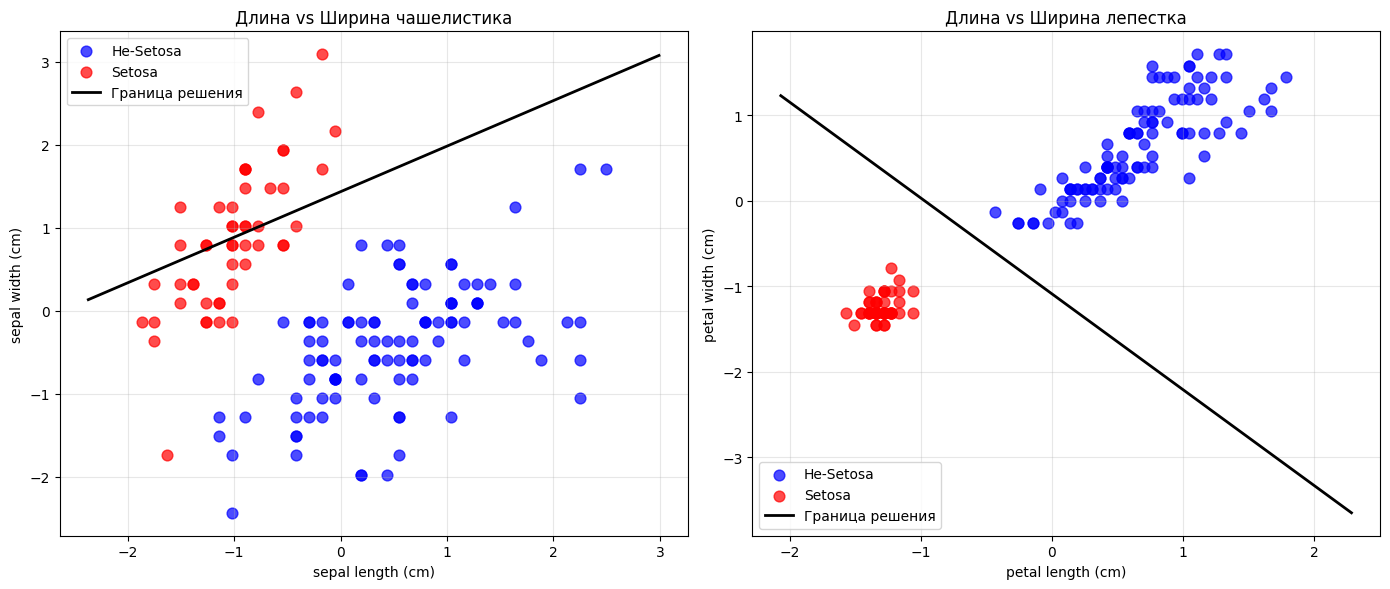

In [6]:
def plot_decision_line_only(nn, X, y, feat1=0, feat2=1):
    X_2d = X[:, [feat1, feat2]]
    
    plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], 
                color='blue', s=60, label='Не-Setosa', alpha=0.7)
    plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], 
                color='red', s=60, label='Setosa', alpha=0.7)
    
    if len(nn.layers) == 1 and len(nn.layers[0].neurons) == 1:
        neuron = nn.layers[0].neurons[0]
        weights = neuron.weights
        bias = weights[-1]  
        
        w1 = weights[feat1]
        w2 = weights[feat2]
        
        x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
        x_line = np.linspace(x_min, x_max, 100)
        
        if abs(w2) > 1e-10:
            y_line = -(w1 * x_line + bias) / w2
            plt.plot(x_line, y_line, 'k-', linewidth=2, label='Граница решения')
        else:
            vertical_x = -bias / w1
            plt.axvline(x=vertical_x, color='k', linewidth=2, label='Граница решения')
    
    feature_names = iris.feature_names
    plt.xlabel(feature_names[feat1])
    plt.ylabel(feature_names[feat2])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(ax1)
plot_decision_line_only(nn, X_scaled, y_binary, 0, 1)
plt.title('Длина vs Ширина чашелистика')

plt.sca(ax2)
plot_decision_line_only(nn, X_scaled, y_binary, 2, 3)
plt.title('Длина vs Ширина лепестка')
plt.show()

In [7]:
iris = load_iris()
X = iris.data
y = iris.target

# Нормализация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot, test_size=0.3, random_state=42
)

# Создаем нейронную сеть с двумя скрытыми слоями и выходным слоем
nn = NeuralNetwork(learning_rate=0.1)
nn.add_layer(num_neurons=10, input_size=4)
nn.add_layer(num_neurons=10, input_size=10)
nn.add_layer(num_neurons=3, input_size=10)

nn.train(X_train, y_train)

# Предсказания
predictions_train = nn.predict(X_train)
predictions_test = nn.predict(X_test)

# Преобразуем вероятности в классы
train_pred_classes = np.argmax(predictions_train, axis=1)
test_pred_classes = np.argmax(predictions_test, axis=1)

train_true_classes = np.argmax(y_train, axis=1)
test_true_classes = np.argmax(y_test, axis=1)

# Вычисляем точность
train_accuracy = np.mean(train_pred_classes == train_true_classes)
test_accuracy = np.mean(test_pred_classes == test_true_classes)

print(f"\nРезультаты многоклассной классификации Iris:")
print(f"Точность на тренировочных данных: {train_accuracy:.2%}")
print(f"Точность на тестовых данных: {test_accuracy:.2%}")



Результаты многоклассной классификации Iris:
Точность на тренировочных данных: 99.05%
Точность на тестовых данных: 97.78%


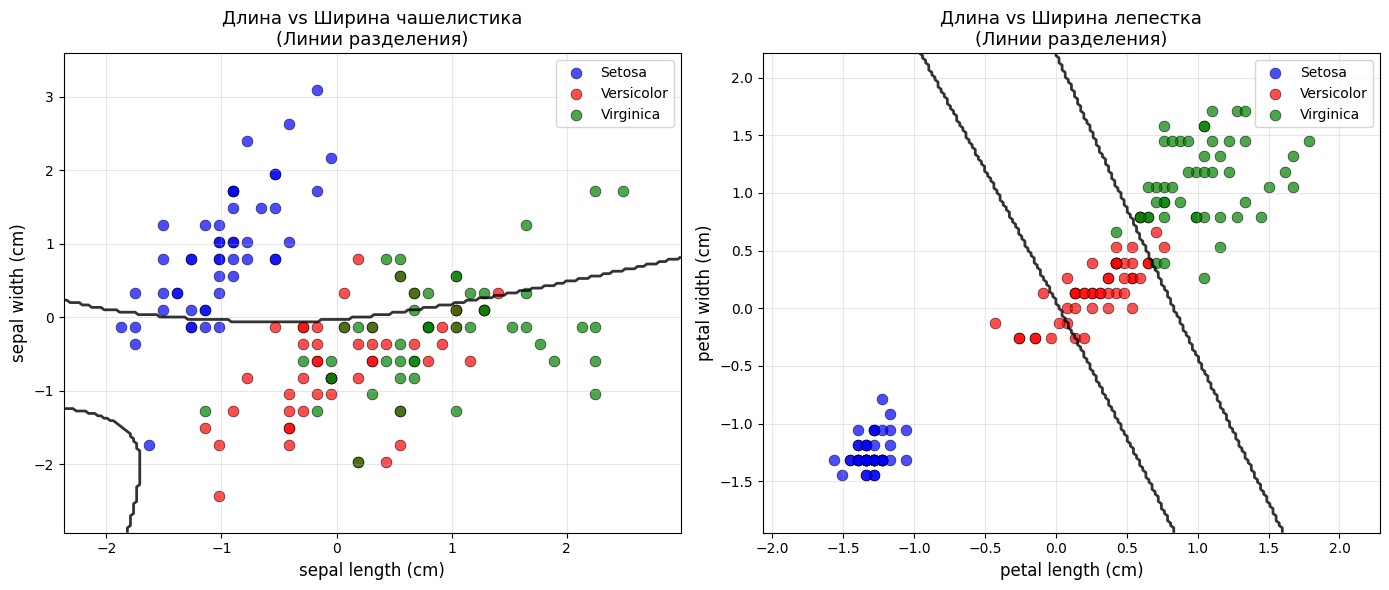

In [8]:
def plot_decision_lines_multi(nn, X, y, feat1=0, feat2=1):
    X_2d = X[:, [feat1, feat2]]
    
    plt.scatter(X_2d[y==0, 0], X_2d[y==0, 1], 
                color='blue', s=60, label='Setosa', alpha=0.7, edgecolor='black', linewidth=0.5)
    plt.scatter(X_2d[y==1, 0], X_2d[y==1, 1], 
                color='red', s=60, label='Versicolor', alpha=0.7, edgecolor='black', linewidth=0.5)
    plt.scatter(X_2d[y==2, 0], X_2d[y==2, 1], 
                color='green', s=60, label='Virginica', alpha=0.7, edgecolor='black', linewidth=0.5)
    

    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    grid_points = np.zeros((xx.ravel().shape[0], X.shape[1]))
    

    for i in range(X.shape[1]):
        if i == feat1:
            grid_points[:, i] = xx.ravel()
        elif i == feat2:
            grid_points[:, i] = yy.ravel()
        else:
            grid_points[:, i] = np.mean(X[:, i])
    
 
    Z = nn.predict(grid_points)
    Z_classes =  np.argmax(Z, axis=1).reshape(xx.shape)
    plt.contour(xx, yy, Z_classes, 
                levels=[0.5, 1.5], 
                colors=['black', 'black'],
                linewidths=[2, 2],
                linestyles=['-', '-'],
                alpha=0.8)
    
    feature_names = iris.feature_names
    plt.xlabel(feature_names[feat1], fontsize=12)
    plt.ylabel(feature_names[feat2], fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(ax1)
plot_decision_lines_multi(nn, X_scaled, y, 0, 1)
plt.title('Длина vs Ширина чашелистика\n(Линии разделения)', fontsize=13)

plt.sca(ax2)
plot_decision_lines_multi(nn, X_scaled, y, 2, 3)
plt.title('Длина vs Ширина лепестка\n(Линии разделения)', fontsize=13)

plt.show()